# MNIST
## 10. Neural Network without NN libraries

In [1]:
from infdsa_mnist import mnist_load_normalized, mnist_output, nn_functions, nn_nolib_output

In the previous notebooks, we have used TensorFlow to guide us through the process of building a neural network. In this notebook, we will build a neural network from scratch without using any NN libraries. NumPy will still be used for our calculations, to ensure we can focus on the neural network implementation rather than the underlying math.

In [2]:
(train_data, test_data) = mnist_load_normalized.load_mnist_flattened_normalized()
x_train, y_train = train_data
x_test, y_test = test_data

### Cross Entropy

Although it is suggested to use One-Hot Encoding for the labels, we will not be using it in this implementation. This would mean that we will use Sparse Categorical Cross Entropy instead of the regular Cross Entropy. The reason for this is that with Sparse Categorical Cross Entropy, we can directly use the integer labels (0-9) without needing to convert them into a one-hot encoded format. This simplifies our implementation and reduces memory usage, as we won't need to create a large matrix for the labels. The loss function will be implemented in a way that it can handle the integer labels directly, making our code more efficient and easier to follow. Do note, however, that when we use backpropagation to update the weights of the neural network, we will have to convert the correct class label into a one-hot encoded format to calculate the gradients correctly. This is because the output of the neural network will be a probability distribution over the classes, and we need to compare it against a one-hot encoded vector to compute the loss and update the weights accordingly.

### Initialization

In order to train a neural network, we first need to pick a few values for our neural network. The actual values of these parameters can be found below. Our input nodes will be 784, which corresponds to the number of features in our flattened MNIST images (28x28 pixels). The output layer will have 10 nodes, corresponding to the 10 digit classes (0-9).

Apart from this, we will need to initialize the weights and biases for our neural network. The weights will be initialized using a random normal distribution, which helps to break symmetry and allows the model to learn effectively. The biases will be initialized to zero for now. This means that initially, the neurons will not have any bias and will rely solely on the weighted sum of the inputs to determine their activation. As training progresses, the weights and biases will be updated through backpropagation to improve the model's performance.

The weight and bias setup will automatically happen when initializing the `NeuralNetwork` class, so we won't need to manually initialize them.

In [3]:
input_nodes = 784
hidden_nodes = 128
output_nodes = 10
nn = nn_functions.NeuralNetwork(input_nodes, hidden_nodes, output_nodes)

### Forward Pass

Before we can train our neural network, we still have to implement our forward pass. The forward pass is the process of passing the input data through the layers of the neural network to obtain the output predictions. In our implementation, we will use input data `X`, weight matrices `weights_input_hidden` and `weights_output_hidden`, and bias vectors `biases_hidden` and `biases_output` to compute the activations of the hidden layer and the output layer. Only `X` needs to be passed as an argument in this notebook, considering the other parameters are known to the `NeuralNetwork` class.

We will return the following values from our forward pass:
- `x_input`: The input data that we passed through the network.
- `h_preac`: The pre-activation values of the hidden layer.
- `h_ac`: The activated values of the hidden layer after applying ReLU.
- `o_preac`: The pre-activation values of the output layer.
- `pred`: The final output predictions of the network after applying softmax.

In [4]:
cache = nn.forward(x_train)

### Backward Pass

Now that we have our forward pass implemented, we can move on to the backward pass, which is the process of calculating gradients and updating the weights and biases of the neural network based on the loss computed from the predictions and the true labels.

In [5]:
weights_and_biases = nn.backward(y_train, cache)

### Training Loop

The training loop is the process of iteratively performing the forward pass, calculating the loss, performing the backward pass to compute gradients, and updating the weights and biases of the neural network. This loop continues for a specified number of epochs or until the model converges to a satisfactory level of performance. In our implementation, we will also include a learning rate to control the step size of the weight updates, and we will track the loss and accuracy over time to monitor the training process.

In [6]:
nn.train_raw(x_train, y_train, learning_rate=0.001, epochs=50)

Epoch 1, Accuracy: 0.1000, Loss: 2.4180
Epoch 2, Accuracy: 0.0986, Loss: 31.1321
Epoch 3, Accuracy: 0.0992, Loss: 31.1143
Epoch 4, Accuracy: 0.1202, Loss: 30.3872
Epoch 5, Accuracy: 0.1127, Loss: 30.6474
Epoch 6, Accuracy: 0.0993, Loss: 31.1091
Epoch 7, Accuracy: 0.0497, Loss: 25.0018
Epoch 8, Accuracy: 0.1475, Loss: 23.8334
Epoch 9, Accuracy: 0.1022, Loss: 23.3086
Epoch 10, Accuracy: 0.0903, Loss: 24.4305
Epoch 11, Accuracy: 0.1043, Loss: 25.4632
Epoch 12, Accuracy: 0.0974, Loss: 25.1077
Epoch 13, Accuracy: 0.1540, Loss: 13.1451
Epoch 14, Accuracy: 0.0986, Loss: 13.5054
Epoch 15, Accuracy: 0.0993, Loss: 14.3639
Epoch 16, Accuracy: 0.0975, Loss: 14.5293
Epoch 17, Accuracy: 0.1022, Loss: 16.1303
Epoch 18, Accuracy: 0.0903, Loss: 15.9924
Epoch 19, Accuracy: 0.0987, Loss: 12.6737
Epoch 20, Accuracy: 0.0992, Loss: 14.1957
Epoch 21, Accuracy: 0.0974, Loss: 14.5438
Epoch 22, Accuracy: 0.0986, Loss: 15.1419
Epoch 23, Accuracy: 0.0993, Loss: 13.9523
Epoch 24, Accuracy: 0.1124, Loss: 14.4539
Ep

#### What is it guessing?

In [7]:
acc_test, loss_test, predicted_digits = nn.evaluate(x_test, y_test)

Test Accuracy: 0.1009, Test Loss: 12.0014


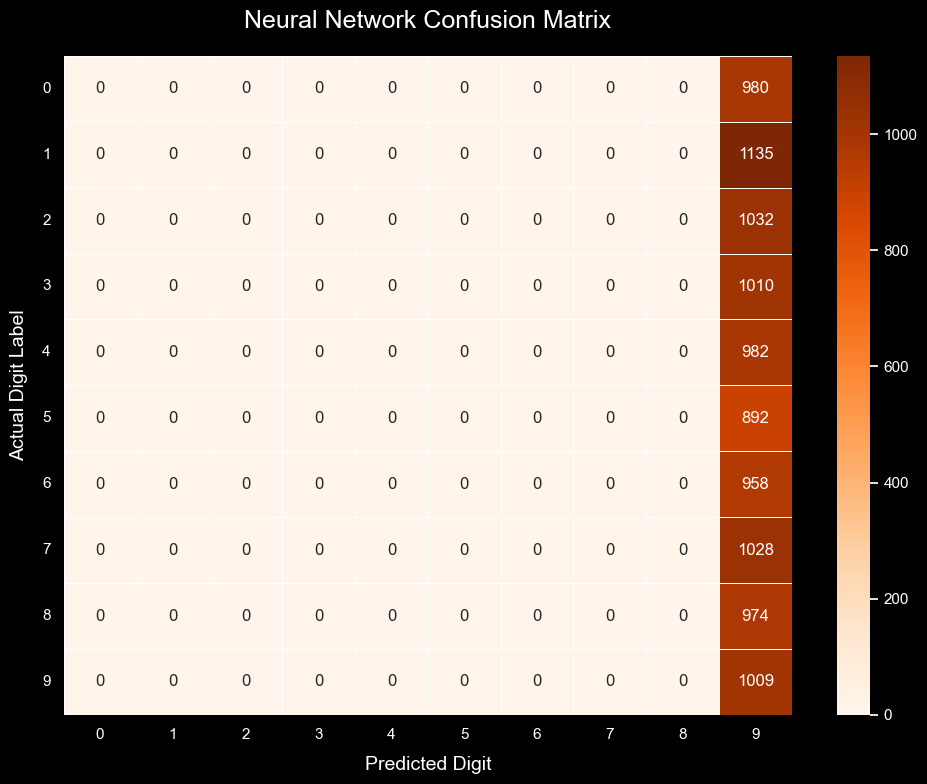

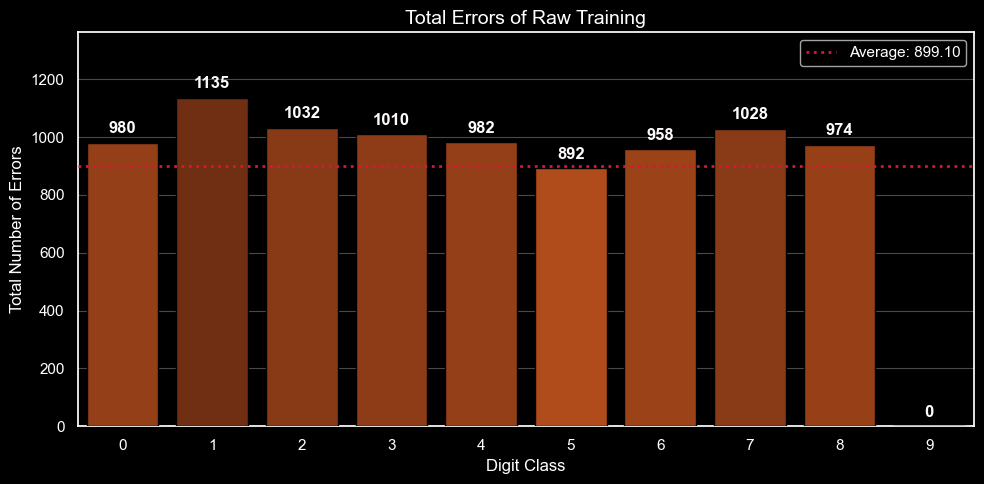

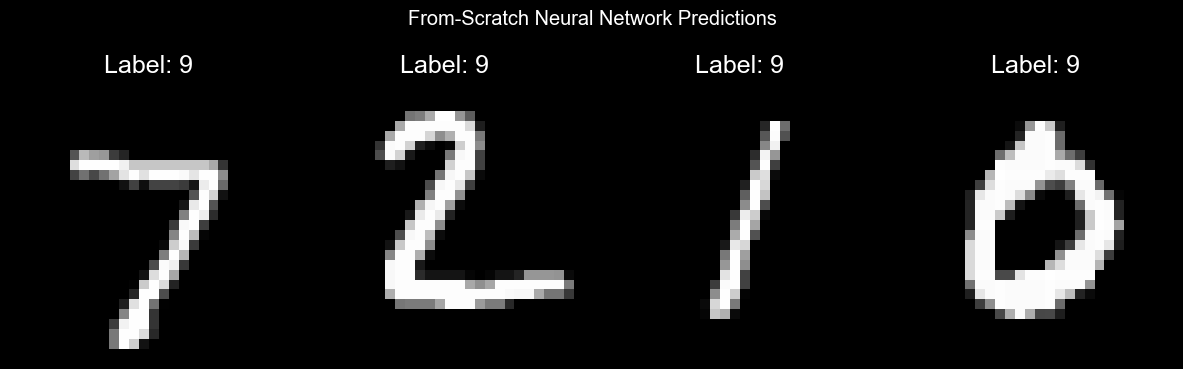

In [8]:
cm = mnist_output.create_confusion_matrix(y_test, predicted_digits)
nn_nolib_output.display_full_confusion_matrix(cm, title="Neural Network Confusion Matrix")
mnist_output.display_total_errors_barplot(cm, title="Total Errors of Raw Training")

unseen_digits_imgs = x_test[0:4].reshape(-1, 28, 28)
mnist_output.display_images(x=unseen_digits_imgs, y=predicted_digits[0:4], title="From-Scratch Neural Network Predictions")

### Explaining the Model's Lack of Performance

Currently, the mode's performance is very poor. The accuracy is around 10%, meaning it's making totally random guesses. In fact, it hones in on a single class and predicts that class for all samples. This is because the weights and biases are only updated after processing the entire training set. This means that the model can't learn effectively from patterns in the data; the gradients are too large and not informative enough to guide the model towards better predictions. The backward propagation cannot make meaningful updates to the weights and biases because of this.

We need to fix this issue. The easiest way to do this is to use batches. This way, updates will be made more frequently, and the gradients will allow for better representation of the patterns in the data. This will allow the model to learn more effectively and improve its performance on the test set.

### Improving the Model's Performance with Batches

To improve the model's performance, we will implement batched training. Before we could train, we should start with a clean slate, so we will reinitialize our weights and biases.

In [9]:
nn = nn_functions.NeuralNetwork(input_nodes, hidden_nodes, output_nodes)
nn.train(x_train, y_train, learning_rate=0.001, epochs=50, batch_size=32)

Epoch 1, Accuracy: 0.8851, Loss: 0.4217
Epoch 2, Accuracy: 0.9356, Loss: 0.2293
Epoch 3, Accuracy: 0.9491, Loss: 0.1812
Epoch 4, Accuracy: 0.9581, Loss: 0.1509
Epoch 5, Accuracy: 0.9637, Loss: 0.1299
Epoch 6, Accuracy: 0.9680, Loss: 0.1142
Epoch 7, Accuracy: 0.9719, Loss: 0.1023
Epoch 8, Accuracy: 0.9745, Loss: 0.0923
Epoch 9, Accuracy: 0.9771, Loss: 0.0842
Epoch 10, Accuracy: 0.9789, Loss: 0.0776
Epoch 11, Accuracy: 0.9802, Loss: 0.0716
Epoch 12, Accuracy: 0.9820, Loss: 0.0666
Epoch 13, Accuracy: 0.9832, Loss: 0.0621
Epoch 14, Accuracy: 0.9843, Loss: 0.0578
Epoch 15, Accuracy: 0.9852, Loss: 0.0544
Epoch 16, Accuracy: 0.9864, Loss: 0.0510
Epoch 17, Accuracy: 0.9871, Loss: 0.0477
Epoch 18, Accuracy: 0.9881, Loss: 0.0450
Epoch 19, Accuracy: 0.9888, Loss: 0.0425
Epoch 20, Accuracy: 0.9894, Loss: 0.0401
Epoch 21, Accuracy: 0.9904, Loss: 0.0379
Epoch 22, Accuracy: 0.9910, Loss: 0.0357
Epoch 23, Accuracy: 0.9916, Loss: 0.0339
Epoch 24, Accuracy: 0.9923, Loss: 0.0320
Epoch 25, Accuracy: 0.992

### Evaluating the Model

As we are at the mercy of our own implementation, we will need to write our own evaluation function to evaluate the performance of our model on the test set. Although this is not difficult to do, as it simply involves performing a forward pass on the test data using the trained weights and biases, it is an important step to ensure that our model is generalizing well to unseen data. The evaluation function will compute the predictions for the test set and compare them against the true labels to calculate the accuracy of the model.

In [10]:
acc_test, loss_test, predicted_digits = nn.evaluate(x_test, y_test)

Test Accuracy: 0.9802, Test Loss: 0.0689


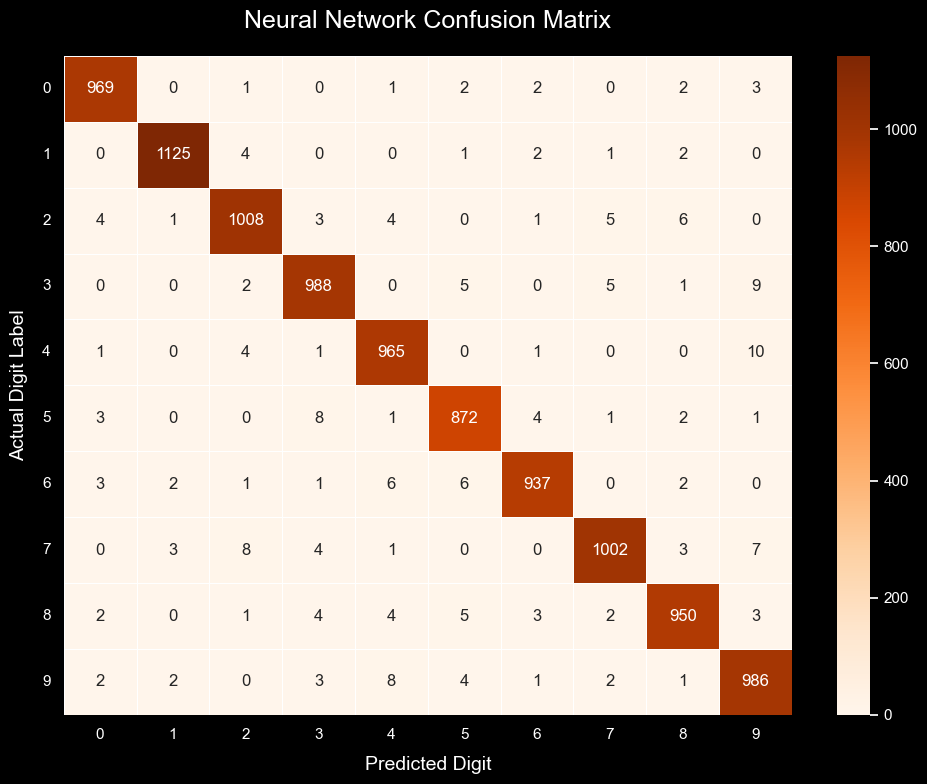

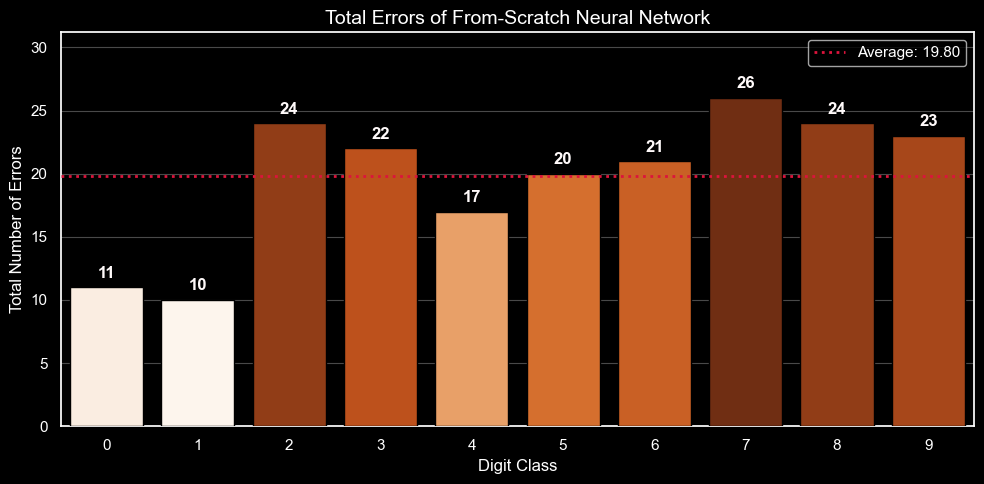

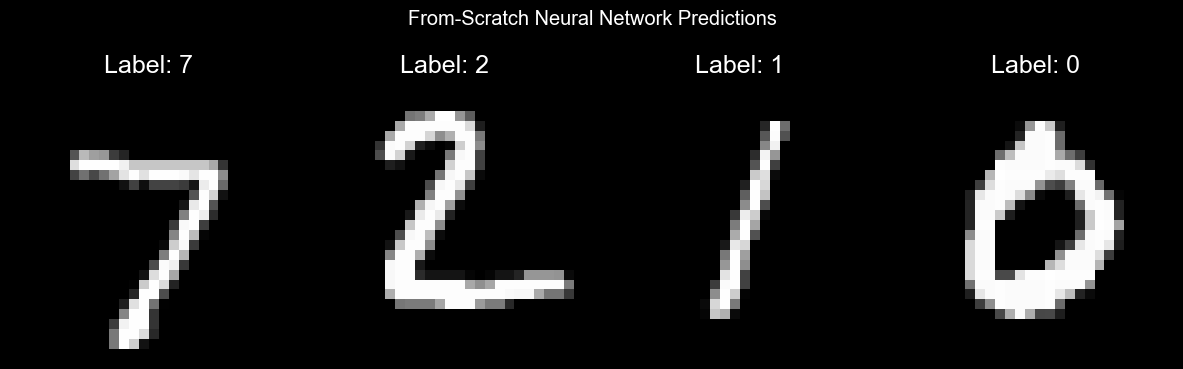

In [11]:
cm = mnist_output.create_confusion_matrix(y_test, predicted_digits)
nn_nolib_output.display_full_confusion_matrix(cm, title="Neural Network Confusion Matrix")
mnist_output.display_total_errors_barplot(cm, title="Total Errors of From-Scratch Neural Network")

unseen_digits_imgs = x_test[0:4].reshape(-1, 28, 28)
mnist_output.display_images(x=unseen_digits_imgs, y=predicted_digits[0:4], title="From-Scratch Neural Network Predictions")

The model achieves around 97+% on the test set, and can achieve over 99+% on the training set. This is a significant improvement from our previous implementation without batches, which had an accuracy of around 10%, where the model grabbed onto a single digit for all its guesses. The use of batches has allowed the model to generalize better and learn more effectively from the training data. However, it is important to note that the performance of the model can be further improved. In chapter 12 we have used Batch Normalization and Dropout, as well as two hidden layers instead of one. These techniques can help bridge the gap between the training and test accuracy, and can help the model learn more complex patterns in the data.

### Improving the Model

To improve the model, we will need to implement Batch Normalization and Dropout. Fortunately, we have found a Batch Normalization implementation on GitHub, since research concluded Batch Normalization is too advanced a technique for us to be able to implement. We have, however, implemented Dropout ourselves, as well as an improved Neural Network that can be spun up with as many Dense layers as one wants. Following a demonstration of how we can build the same neural network as we built using TensorFlow in chapter 12.

In [12]:
model = nn_functions.ImprovedNeuralNetwork(
    input_nodes=input_nodes,
    hidden_layer_sizes=[256, 64],
    output_nodes=output_nodes,
    dropout_rates=[0.15, 0.05]
)

In [13]:
model.train(x_train, y_train, learning_rate=0.001, epochs=50, batch_size=32, verbose=True, val_split=0.1, patience=12)

Epoch 1, Accuracy: 0.8878, Loss: 0.3878, Val Loss: 0.1494
Epoch 2, Accuracy: 0.9389, Loss: 0.2045, Val Loss: 0.1116
Epoch 3, Accuracy: 0.9527, Loss: 0.1582, Val Loss: 0.0943
Epoch 4, Accuracy: 0.9592, Loss: 0.1339, Val Loss: 0.0866
Epoch 5, Accuracy: 0.9635, Loss: 0.1152, Val Loss: 0.0801
Epoch 6, Accuracy: 0.9675, Loss: 0.1030, Val Loss: 0.0821
Epoch 7, Accuracy: 0.9710, Loss: 0.0933, Val Loss: 0.0798
Epoch 8, Accuracy: 0.9728, Loss: 0.0846, Val Loss: 0.0701
Epoch 9, Accuracy: 0.9729, Loss: 0.0812, Val Loss: 0.0709
Epoch 10, Accuracy: 0.9762, Loss: 0.0743, Val Loss: 0.0717
Epoch 11, Accuracy: 0.9790, Loss: 0.0674, Val Loss: 0.0698
Epoch 12, Accuracy: 0.9787, Loss: 0.0655, Val Loss: 0.0669
Epoch 13, Accuracy: 0.9797, Loss: 0.0625, Val Loss: 0.0679
Epoch 14, Accuracy: 0.9811, Loss: 0.0567, Val Loss: 0.0672
Epoch 15, Accuracy: 0.9816, Loss: 0.0570, Val Loss: 0.0679
Epoch 16, Accuracy: 0.9828, Loss: 0.0541, Val Loss: 0.0670
Epoch 17, Accuracy: 0.9838, Loss: 0.0496, Val Loss: 0.0720
Epoch 

In [14]:
acc_test, loss_test, predicted_digits = model.evaluate(x_test, y_test)

Test Accuracy: 0.9823, Test Loss: 0.0601


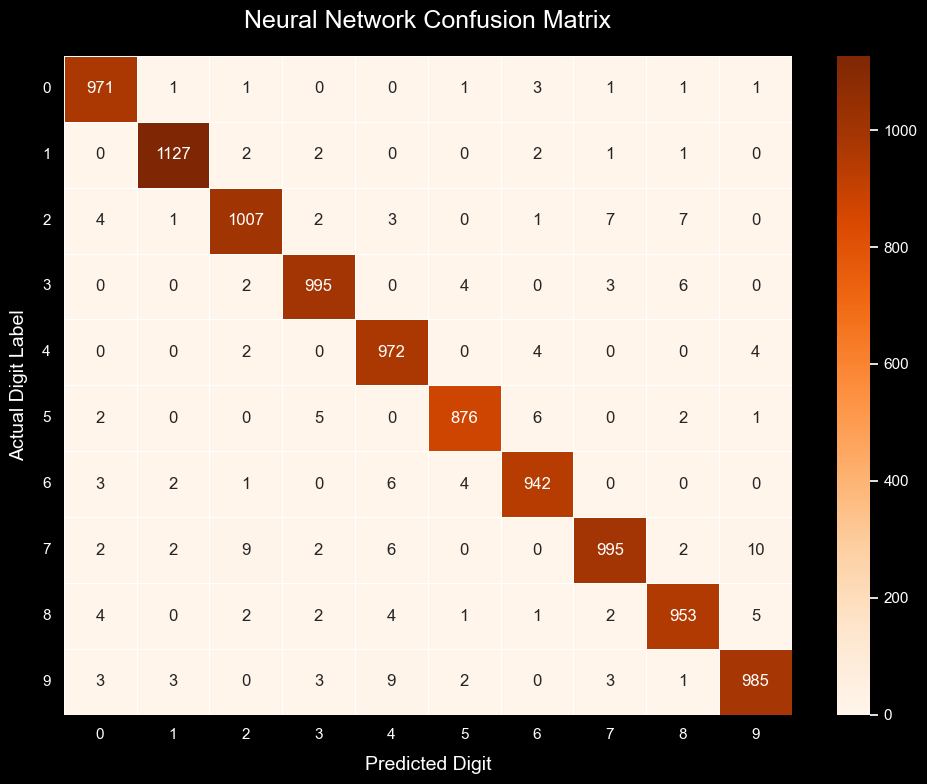

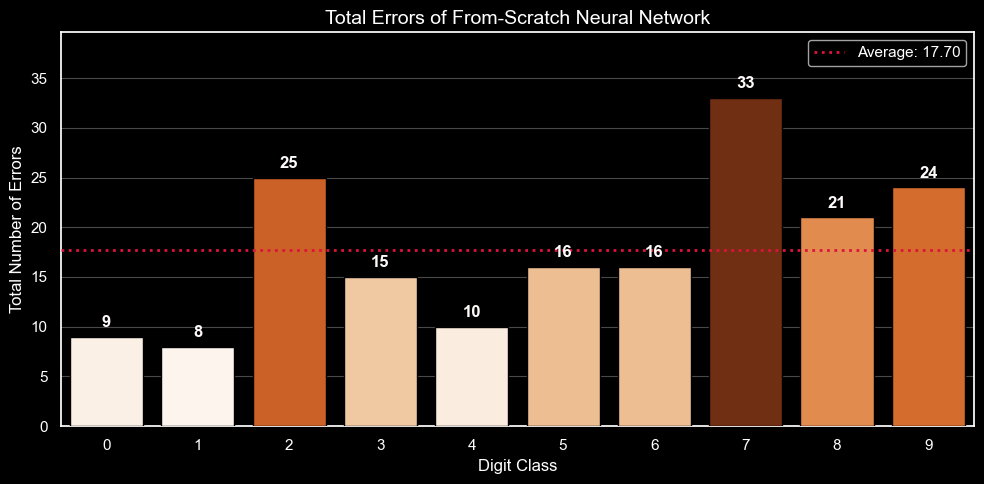

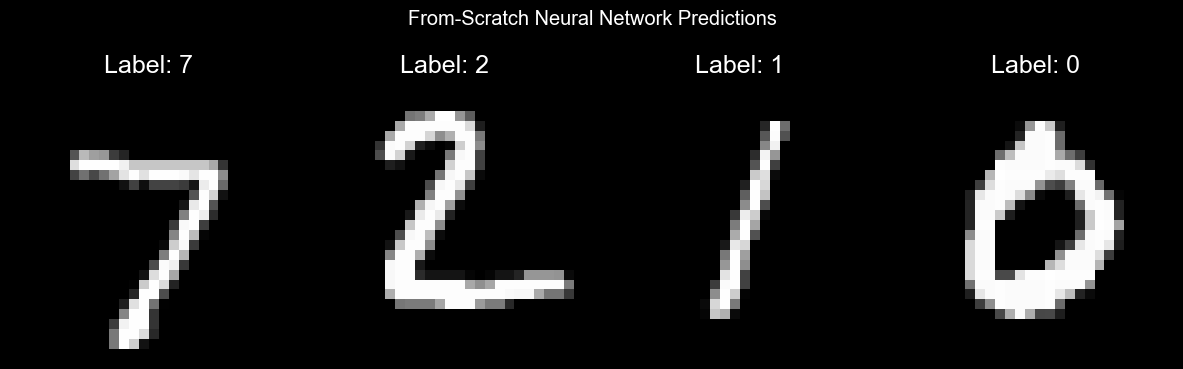

In [15]:
cm = mnist_output.create_confusion_matrix(y_test, predicted_digits)
nn_nolib_output.display_full_confusion_matrix(cm, title="Neural Network Confusion Matrix")
mnist_output.display_total_errors_barplot(cm, title="Total Errors of From-Scratch Neural Network")

unseen_digits_imgs = x_test[0:4].reshape(-1, 28, 28)
mnist_output.display_images(x=unseen_digits_imgs, y=predicted_digits[0:4], title="From-Scratch Neural Network Predictions")

The improved model does not improve much on actual results. However, the training is now more efficient, stopping early when the validation loss hasn't improved for a while. The training accuracy is lower because of this and the test accuracy floats around the same percentage as the previous model. However, the percentages for training and testing are much closer to each other, which indicates the model is generalizing better and is not overfitting nearly as much as the previous model.

For this reason, we accept the lower training accuracy in favor of the improved generalization, as it is more honest to the model's actual performance on unseen data.